# Dataset
## Telco Customer Churn: IBM dataset

- **CustomerID**: A unique ID that identifies each customer.
- **Count**: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.
- **Country**: The country of the customer’s primary residence.
- **State**: The state of the customer’s primary residence.
- **City**: The city of the customer’s primary residence.
- **Zip** **Code**: The zip code of the customer’s primary residence.
- **Latitude**: The latitude of the customer’s primary residence.
- **Lat Long**: The combined latitude and longitude of the customer’s primary residence.
- **Longitude**: The longitude of the customer’s primary residence.
- **Gender**: The customer’s gender: Male, Female
- **Senior** **Citizen**: Indicates if the customer is 65 or older: Yes, No
- **Partner**: Indicate if the customer has a partner: Yes, No
- **Dependents**: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.
- **Tenure Months**: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.
- **Phone Service**: Indicates if the customer subscribes to home phone service with the company: Yes, No
- **Multiple Lines**: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No
- **Internet Service**: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.
- **Online Security**: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No
- **Online Backup**: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No
- **Device Protection**: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No
- **Tech Support**: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No
- **Streaming TV**: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.
- **Streaming Movies**: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.
- **Contract**: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.
- **Paperless Billing**: Indicates if the customer has chosen paperless billing: Yes, No
- **Payment Method**: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check
- **Monthly Charge**: Indicates the customer’s current total monthly charge for all their services from the company.
- **Total Charges**: Indicates the customer’s total charges, calculated to the end of the quarter specified above.
- **Churn Label**: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.
- **Churn Value**: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.
- **Churn Score**: A value from 0–100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.
- **CLTV**: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.
- **Churn Reason**: A customer’s specific reason for leaving the company. Directly related to Churn Category.

# Setup

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import mlflow

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('telco_customer_churn')

pd.set_option('display.max_columns', None)
sns.set_theme(style='darkgrid')
sns.set_palette(sns.color_palette('colorblind6'))


2026/08/27 00:28:25 INFO mlflow.tracking.fluent: Experiment with name 'telco_customer_churn' does not exist. Creating a new experiment.


In [3]:
df = pd.read_excel('../data/Telco_customer_churn.xlsx')

In [4]:
df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape

(7043, 33)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

- Aparentemente apenas a coluna ```Churn Reason``` tem entradas vazias. 
- ```Zip Code``` como int64 não é o ideal, já que não precisaremos realizar operações matemáticas nela.
- ```Total Charges``` como object é suspeito.

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"34.159534, -116.425984",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- ```Customer ID``` não tem valor de análise, sendo apenas uma chave de identidade.
- ```Count```, como descrito pelo catálogo de dados, serve apenas para contagem de entradas.
- ```Country``` e ```State``` contém apenas valores únicos (*United States* e *California*, respectivamente).
- ```Lat Long``` aparenta ser apenas a junção entre ```Latitude``` e ```Longitude```.
- ```Total Charges``` como objeto impossiblitou descrição de medidas.
<!-- - ```Churn Label``` e ```Churn Value``` estão diretamente relacionados como exposto pelo catálogo de dados. -->

In [8]:
# Renomear colunas para trabalho mais eficiente: snake_case
df.rename(columns=lambda x: x.replace(' ', '_').lower(), inplace=True)

In [9]:
# Removendo colunas sem valor analítico.
# 'churn_label' está diretamente relacionado com 'churn_value'.
df.drop(columns=['customerid', 'count', 'country', 'state', 'lat_long', 'churn_label'], inplace=True)

In [10]:
# Verificando a questão do df['total_charges']
try:
    pd.to_numeric(df['total_charges'])
except ValueError as e:
    print(e)

Unable to parse string " " at position 2234


In [11]:
# Verificando quantas linhas contem " "
df['total_charges'].str.isspace().sum()

11

In [12]:
# Imputando a mediana no lugar das entradas inválidas
if df['total_charges'].dtype.name == 'object':
    total_charges = pd.to_numeric(df['total_charges'], errors='coerce')
    mediana = total_charges.median()
    mask = df['total_charges'].str.contains(' ', na=False)
    df.loc[mask, 'total_charges'] = mediana
    df['total_charges'] = df['total_charges'].astype(float)

df['total_charges'].describe()

count    7043.000000
mean     2281.916928
std      2265.270398
min        18.800000
25%       402.225000
50%      1397.475000
75%      3786.600000
max      8684.800000
Name: total_charges, dtype: float64

In [13]:
# Transformando zip_code em string.
df['zip_code'] = df['zip_code'].astype(str)

# Missing Values

In [14]:
missing_values = pd.DataFrame({
    'coluna': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_perc': (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing_values[missing_values['missing_count'] > 0].sort_values(by='missing_perc', ascending=False))

                    coluna  missing_count  missing_perc
churn_reason  churn_reason           5174         73.46


- Apenas a coluna ```churn_reason``` apresenta missing values.
    - Número de linhas com dados faltantes é igual ao número de clientes sem Churn, indicando que todos os Churns tem churn_reason.

In [15]:
if df[df['churn_value'] == 1]['churn_reason'].isnull().sum() == 0:  # churn_value == 1 -> Churn
    print('Todos os churns tem churn_reason')
else:
    print('Nem todos os churns tem churn_reason')

Todos os churns tem churn_reason


In [16]:
df['churn_reason'].value_counts()

churn_reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

- 3 das Top 5 razões de churn envolvem comparações com concorrentes.
- 2 das Top 6 envolvem atitudes de profissionais da empresa.

# Análise

In [17]:
df.columns

Index(['city', 'zip_code', 'latitude', 'longitude', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'churn_value', 'churn_score',
       'cltv', 'churn_reason'],
      dtype='object')

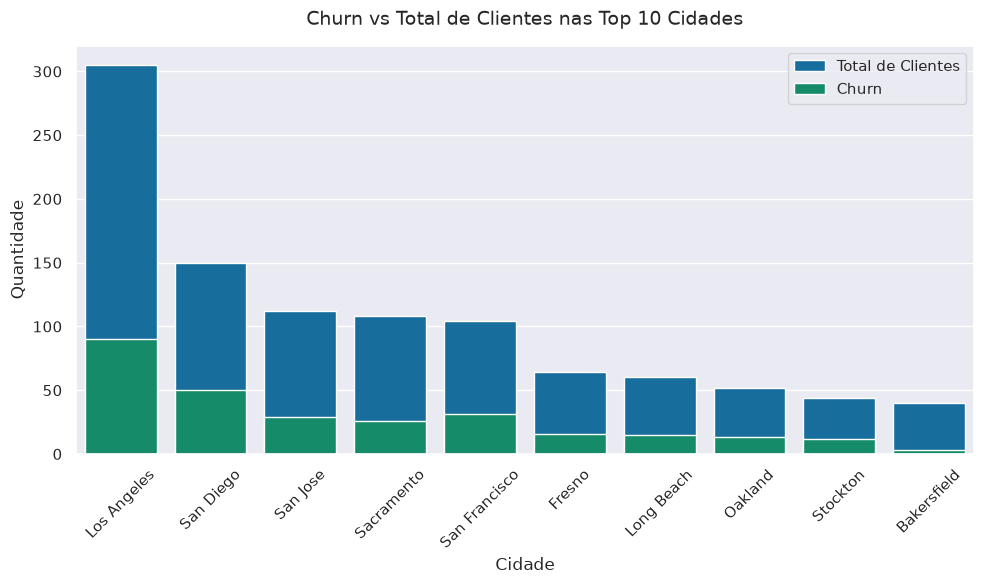

In [18]:
top10_cidades = df['city'].value_counts().head(10).index

df_top10 = df[df['city'].isin(top10_cidades)]

total_clientes = df_top10['city'].value_counts()
total_churn = df_top10[df_top10['churn_value'] == 1]['city'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=total_clientes.index,
    y=total_clientes.values,
    ax=ax,
    label='Total de Clientes',
)

sns.barplot(
    x=total_churn.index,
    y=total_churn.values,
    ax=ax,
    label='Churn',
)

ax.set_title('Churn vs Total de Clientes nas Top 10 Cidades', fontsize=14, pad=15)
ax.set_xlabel('Cidade')
ax.set_ylabel('Quantidade')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Taxa de churn parece se manter relativamente constante entre cidades.

In [19]:
df.groupby('city')['churn_value'].mean().describe().round(2)

count    1129.00
mean        0.26
std         0.22
min         0.00
25%         0.00
50%         0.25
75%         0.40
max         1.00
Name: churn_value, dtype: float64

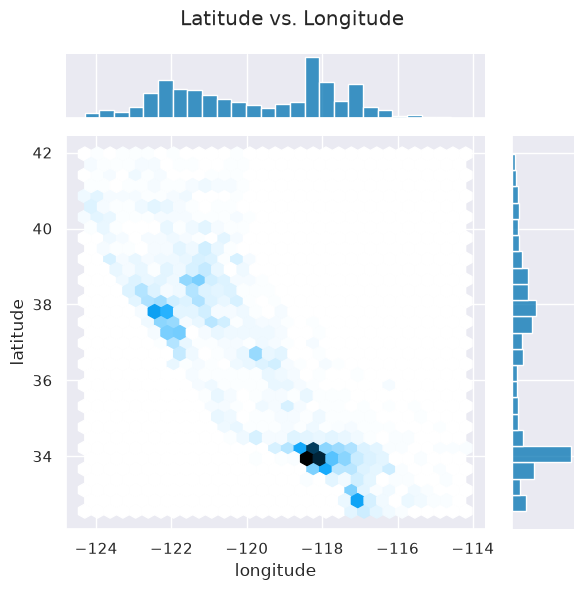

In [20]:
sns.jointplot(
    x='longitude',
    y='latitude',
    data=df,
    kind='hex',
    height=6,
    gridsize=30,
)

plt.suptitle('Latitude vs. Longitude')
plt.tight_layout()
plt.show()

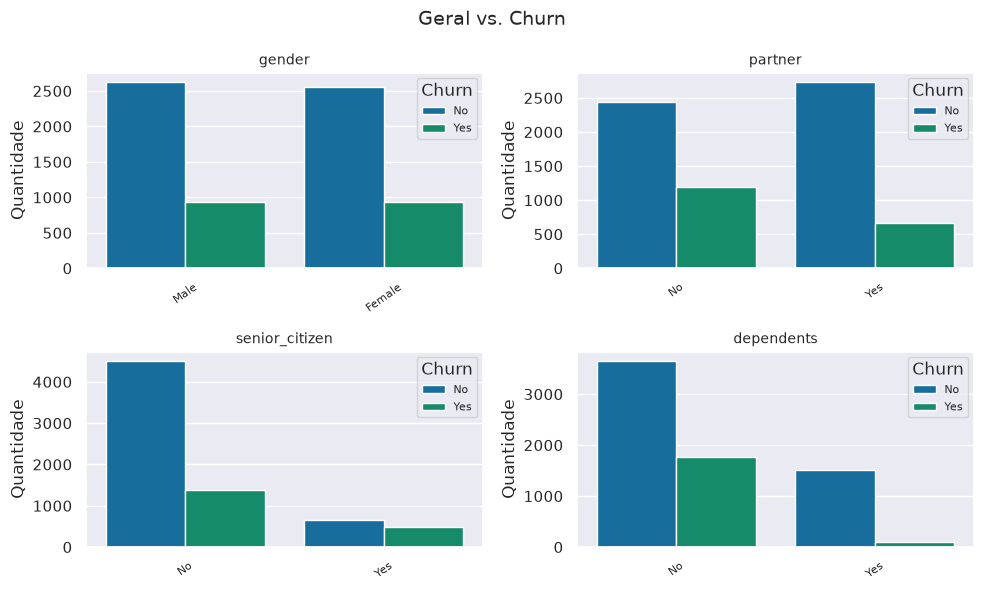

In [21]:
socio_cols = ['gender', 'partner', 'senior_citizen', 'dependents']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
axes = axes.ravel()

for i, col in enumerate(socio_cols):
    sns.countplot(
        data=df,
        x=col,
        hue='churn_value',
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Quantidade')
    axes[i].tick_params(axis='x', rotation=35, labelsize=8)
    axes[i].legend(title='Churn', labels=['No', 'Yes'], fontsize=8)

plt.suptitle('Geral vs. Churn', fontsize=14)
plt.tight_layout()
plt.show()

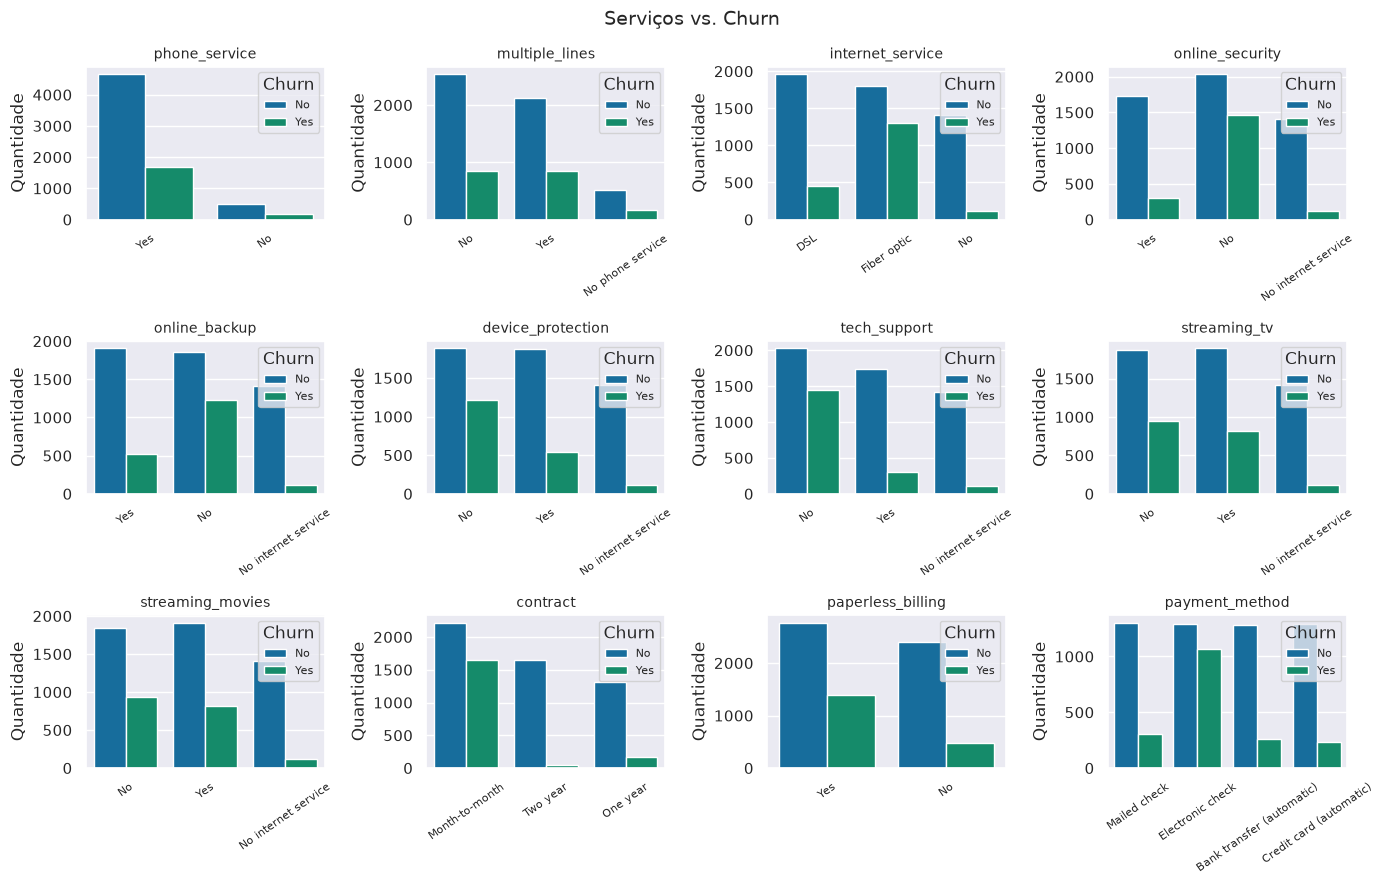

In [22]:
service_cols = ['phone_service', 'multiple_lines', 'internet_service', 'online_security',
                'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
                'streaming_movies', 'contract', 'paperless_billing', 'payment_method']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(14, 9))
axes = axes.ravel()

for i, col in enumerate(service_cols):
    sns.countplot(
        data=df,
        x=col,
        hue='churn_value',
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Quantidade')
    axes[i].tick_params(axis='x', rotation=35, labelsize=8)
    axes[i].legend(title='Churn', labels=['No', 'Yes'], fontsize=8)

plt.suptitle('Serviços vs. Churn', fontsize=14)
plt.tight_layout()
plt.show()


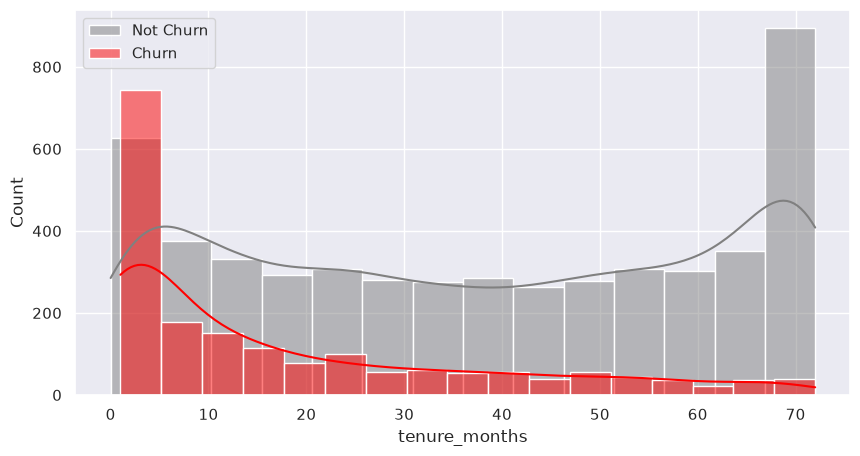

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df.query('churn_value == 0'),
    x='tenure_months',
    label='Not Churn',
    color='gray',
    kde=True
)

sns.histplot(
    data=df.query('churn_value == 1'),
    x='tenure_months',
    label='Churn',
    color='red',
    kde=True
)

plt.legend()
plt.show()

## Outliers

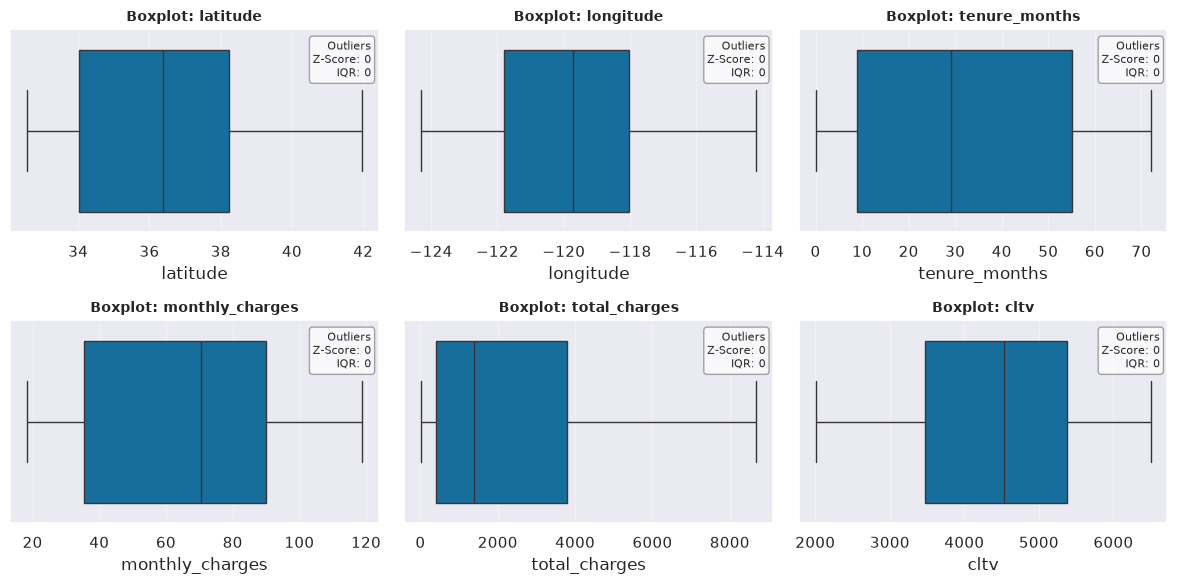

In [24]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(
    ['churn_value', 'churn_score'], errors='ignore'
)

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
axes = axes.ravel()

for col, ax in zip(numeric_cols, axes):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f'Boxplot: {col}', fontweight='bold', fontsize=10)
    ax.set_xlabel(col)
    ax.grid(axis='x', alpha=0.3)

    series = df[col].dropna()

    # Z-Score (>3)
    std = series.std()
    if std > 0 and pd.notna(std):
        z_scores = ((series - series.mean()) / std).abs()
        outliers_zscore_count = (z_scores > 3).sum()
    else:
        outliers_zscore_count = 0

    # IQR
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outlier_mask_iqr = (series < lim_inf) | (series > lim_sup)
    outliers_iqr_count = outlier_mask_iqr.sum()

    ax.text(
        0.98, 0.95,
        f'Outliers\nZ-Score: {outliers_zscore_count}\nIQR: {outliers_iqr_count}',
        transform=ax.transAxes,
        fontsize=8,
        va='top',
        ha='right',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.3')
    )

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Skewness & Kurtosis

         Coluna  Skewness  Kurtosis    Média  Mediana     Moda         Interpretação
       latitude     0.304    -1.136   36.282   36.392   32.556                Normal
      longitude    -0.041    -1.136 -119.799 -119.731 -121.995                Normal
  tenure_months     0.240    -1.387   32.371   29.000    1.000                Normal
monthly_charges    -0.221    -1.257   64.762   70.350   20.050                Normal
  total_charges     0.964    -0.226 2281.917 1397.475   20.200 Assimétrica à direita
           cltv    -0.312    -0.934 4400.296 4527.000 5546.000                Normal


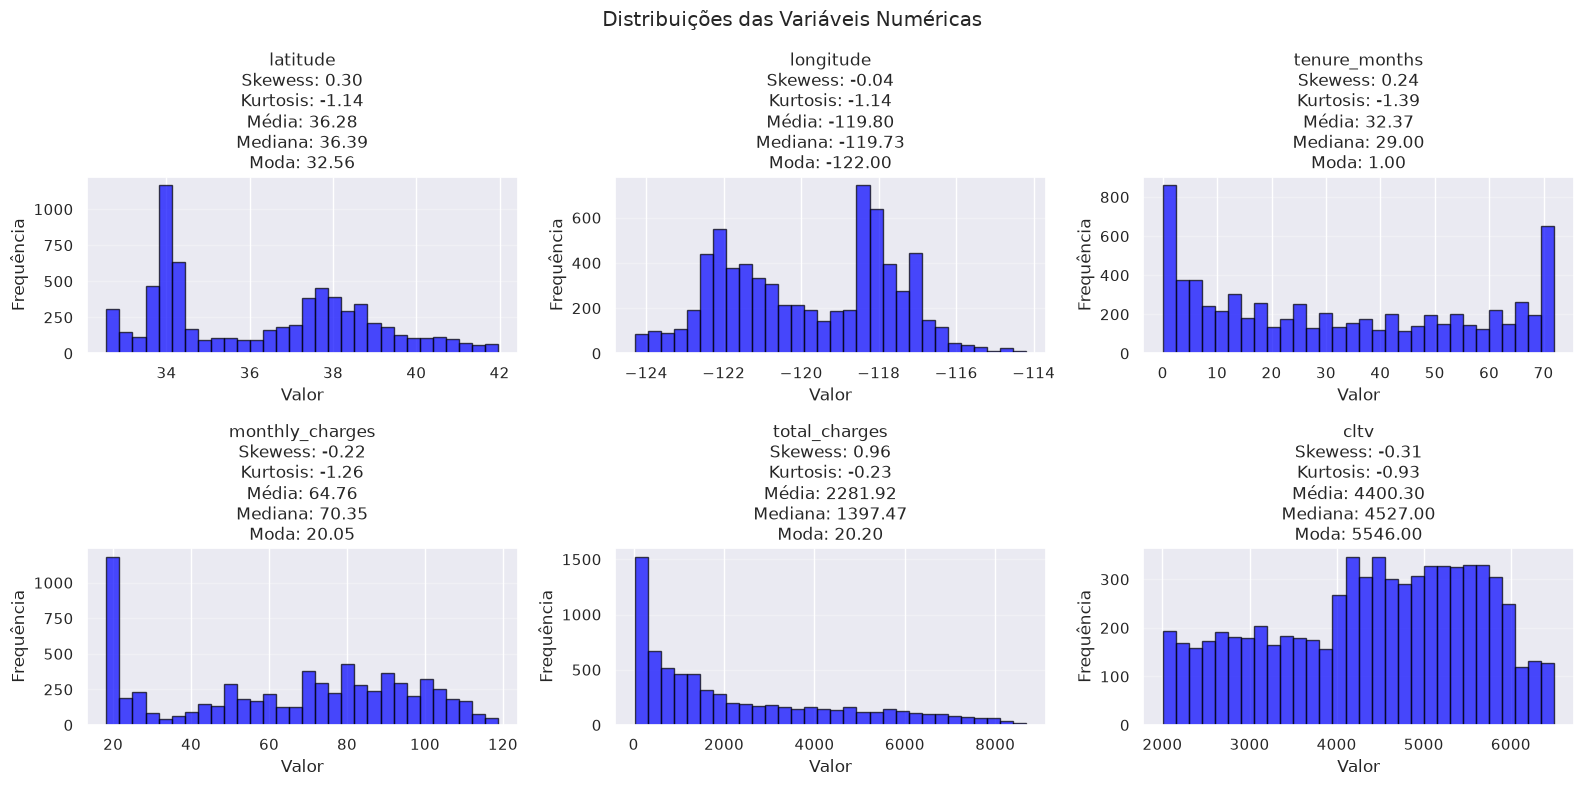

In [25]:
moda_por_coluna = df[numeric_cols].mode(dropna=True).iloc[0]

dist_df = pd.DataFrame({
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurt(),
    'Média': df[numeric_cols].mean(),
    'Mediana': df[numeric_cols].median(),
    'Moda': moda_por_coluna
}).round(3).reset_index().rename(columns={'index': 'Coluna'})

condicoes = [
    dist_df['Skewness'].isna(),
    dist_df['Skewness'].abs() < 0.5,
    dist_df['Skewness'] > 0
]
escolhas = ['N/A', 'Normal', 'Assimétrica à direita']
dist_df['Interpretação'] = np.select(condicoes, escolhas, default='Assimétrica à esquerda')

print(dist_df.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for col, ax in zip(numeric_cols, axes):
    skew_val = dist_df.loc[dist_df['Coluna'] == col, 'Skewness'].values[0]
    kurt_val = dist_df.loc[dist_df['Coluna'] == col, 'Kurtosis'].values[0]
    mean_val = dist_df.loc[dist_df['Coluna'] == col, 'Média'].values[0]
    median_val = dist_df.loc[dist_df['Coluna'] == col, 'Mediana'].values[0]
    mode_val = dist_df.loc[dist_df['Coluna'] == col, 'Moda'].values[0]

    ax.hist(df[col].dropna(), bins=30, color='blue', edgecolor='black', alpha=0.7)
    ax.set_title(
        f'{col}\nSkewess: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}\nMédia: {mean_val:.2f}\nMediana: {median_val:.2f}\nModa: {mode_val:.2f}')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
    ax.grid(axis='y', alpha=0.3)

for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

plt.suptitle('Distribuições das Variáveis Numéricas')
plt.tight_layout()
plt.show()

- ```total_charges``` apresentou assimetria à direita. Aplicar transformação.

## Matriz de correlação

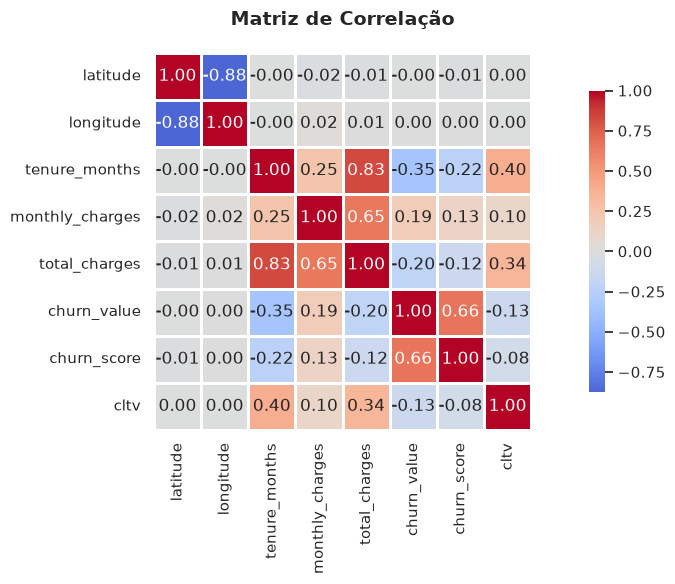

In [26]:
corr_numeric = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

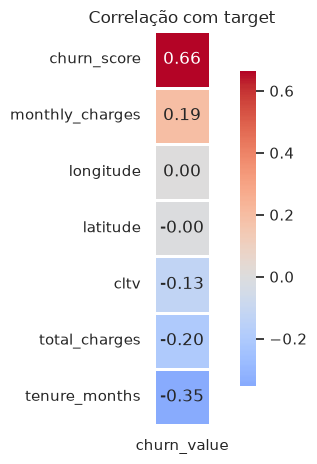

In [27]:
sns.heatmap(
    corr_numeric[['churn_value']].sort_values(by='churn_value', ascending=False).drop('churn_value'),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlação com target')
plt.tight_layout()
plt.show()

# Baseline

In [28]:
df.columns

Index(['city', 'zip_code', 'latitude', 'longitude', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'churn_value', 'churn_score',
       'cltv', 'churn_reason'],
      dtype='object')

In [29]:
df_base = df[[
    'gender', 'senior_citizen', 'partner', 'dependents',
    'tenure_months', 'phone_service', 'multiple_lines', 'internet_service',
    'online_security', 'online_backup', 'device_protection', 'tech_support',
    'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
    'payment_method', 'monthly_charges', 'total_charges',
    'cltv', 'churn_value',
]].copy()

df_base.head()

,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cltv,churn_value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,3239,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,2701,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,5372,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,5003,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,5340,1


In [30]:
df_base['multiple_lines'] = df_base['multiple_lines'].replace('No phone service', 'No')

dependentes = [
    'online_security', 'online_backup', 'device_protection', 'tech_support',
    'streaming_tv', 'streaming_movies'
]

df_base[dependentes] = df_base[dependentes].replace('No internet service', 'No')

In [31]:
cat_cols = [
    'gender', 'senior_citizen', 'partner', 'dependents',
    'phone_service', 'multiple_lines', 'internet_service', 'online_security',
    'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
    'streaming_movies', 'contract', 'paperless_billing', 'payment_method'
]

df_encoded = pd.get_dummies(df_base, columns=cat_cols, drop_first=True, dtype='int')

df_encoded.shape

(7043, 25)

In [32]:
X = df_encoded.drop(columns='churn_value')
y = df_encoded['churn_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

scale_cols = ['tenure_months', 'monthly_charges', 'total_charges', 'cltv']

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [33]:
X_train

,tenure_months,monthly_charges,total_charges,cltv,gender_Male,senior_citizen_Yes,partner_Yes,dependents_Yes,phone_service_Yes,multiple_lines_Yes,internet_service_Fiber optic,internet_service_No,online_security_Yes,online_backup_Yes,device_protection_Yes,tech_support_Yes,streaming_tv_Yes,streaming_movies_Yes,contract_One year,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
4626,0.102371,-0.521976,-0.263289,-1.372236,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,1,0
4192,-0.711743,0.337478,-0.504814,0.194486,1,0,1,1,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1
5457,-0.793155,-0.809013,-0.751213,-1.274104,1,0,1,1,0,0,0,0,1,1,0,1,0,0,0,1,0,0,0,1
4717,-0.263980,0.284384,-0.173699,-0.683623,0,0,1,0,1,0,0,0,0,1,1,0,1,1,0,1,1,1,0,0
4673,-1.281624,-0.676279,-0.990851,-0.842664,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6507,1.567778,1.470695,2.373711,0.541331,0,0,1,0,1,1,1,0,0,1,1,1,1,1,0,1,0,0,1,0
1646,-1.240918,-0.626504,-0.975133,0.218173,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1222,-0.304686,1.256662,0.157569,0.477884,0,1,0,0,1,1,1,0,1,1,0,0,1,1,0,0,1,0,0,1
3870,-0.345392,-1.477661,-0.798434,-1.127753,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0


In [34]:

with mlflow.start_run(run_name='logistic_regression_etapa1') as run:
    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metrics = {
        'train_accuracy': accuracy_score(y_train, y_pred_train),
        'test_accuracy': accuracy_score(y_test, y_pred_test),
        'test_precision': precision_score(y_test, y_pred_test),
        'test_recall': recall_score(y_test, y_pred_test),
        'test_f1': f1_score(y_test, y_pred_test),
        'train_roc_auc': roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]),
        'test_roc_auc': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    }

    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(model, 'logistic_regression_model') # type: ignore

2026/08/27 00:28:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/27 00:28:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run logistic_regression_etapa1 at: http://localhost:5000/#/experiments/1/runs/5d9e957b126c4028b172fb6bf5bd9602
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [35]:
print('Logistic Regression Baseline:\n')
print(f'Train Accuracy: {metrics["train_accuracy"]:.4f}')
print(f'Test Accuracy: {metrics["test_accuracy"]:.4f}')
print(f'Test Precision: {metrics["test_precision"]:.4f}')
print(f'Test Recall: {metrics["test_recall"]:.4f}')
print(f'Test F1: {metrics["test_f1"]:.4f}\n')

print(f'Train ROC-AUC: {metrics["train_roc_auc"]:.4f}')
print(f'Test ROC-AUC: {metrics["test_roc_auc"]:.4f}')

Logistic Regression Baseline:

Train Accuracy: 0.8136
Test Accuracy: 0.8034
Test Precision: 0.6456
Test Recall: 0.5749
Test F1: 0.6082

Train ROC-AUC: 0.8622
Test ROC-AUC: 0.8490


In [36]:
# Talvez colocar o df_encoded direto no notebook model_comparison?
# df_encoded.to_csv('../data/telco_customer_churn_preprocessed.csv', index=False)

joblib.dump(model, '../models/baseline_model.joblib')

['../models/baseline_model.joblib']